# Lecture: Relationships Between Quantitative Features

In Week 2, we compared a quantitative feature across categories. Now we examine how two quantitative features vary together, use a linear model to summarize an approximately straight relationship, and ask whether categorical features add useful information.


## Learning goals

By the end of this lesson, you should be able to:

- create and interpret a scatterplot;
- describe a relationship's direction, form, strength, and unusual observations;
- calculate and interpret a correlation;
- use a fitted line to calculate predicted values and residuals;
- interpret a slope and an R-squared value in context;
- use a residual plot to evaluate whether a line captures the main pattern;
- use color to examine whether a categorical feature adds information to a quantitative relationship; and
- recognize situations in which a linear model is not a useful summary.


## Import the libraries


Import NumPy, Pandas, Matplotlib's `pyplot` component, and Seaborn using their conventional aliases.

**NumPy** provides efficient numerical calculations with arrays. Pandas uses NumPy internally, and later in this lesson we will use NumPy to fit a model containing several predictors.


In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

# County income and life expectancy

The County Health Rankings & Roadmaps program assembles measures of population health and community conditions for U.S. counties. Economic resources can shape access to housing, food, education, health care, transportation, and safer environments. That motivates a genuine—but carefully limited—research question about income and health.


## The reproducible analysis workflow

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can answer the question?
3. **Operation:** What should the code select, calculate, or model?
4. **Check:** Does the result have sensible rows, values, units, and missingness?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Step 1 — Question

> **How was median household income related to life expectancy across U.S. counties in the 2025 County Health Rankings release?**
>
> **Did this relationship depend on resident age or access to primary-care physicians?**

We expect that counties with greater income may also have greater life expectancy, but the relationship is not automatic. Counties with similar incomes can differ in demographics, environments, health-care access, public policy, and many other conditions.


## Discussion: predict the relationship and target

1. What direction do you predict for the relationship between income and life expectancy?

2. Which feature should be the target and which should be used as the predictor?


Life expectancy is the target and median income is the predictor 

## Step 2 — Data

Read the fixed local dataset. The FIPS code is an identifier rather than a quantity, so `dtype={"county_fips": "string"}` preserves leading zeros and prevents arithmetic from being applied to it.


In [5]:
county_health = pd.read_csv('data/county_health_rankings_2025.csv', dtype={"county_fips": "string"})
county_health.head()

,county_fips,county,state,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000
0,02013,Aleutians East Borough,AK,83000.0,NaN,9.505923,NaN
1,02016,Aleutians West Census Area,AK,104159.0,85.915167,7.054264,59.30026
2,02020,Anchorage Borough,AK,93881.0,76.342569,13.294416,116.27059
3,02050,Bethel Census Area,AK,62140.0,68.864695,8.850966,86.22083
4,02060,Bristol Bay Borough,AK,99790.0,NaN,20.142180,0.00000


In [6]:
county_health.tail()

,county_fips,county,state,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000
3139,56037,Sweetwater County,WY,76442.0,74.630018,15.668259,43.25467
3140,56039,Teton County,WY,130156.0,87.576928,18.526171,93.31919
3141,56041,Uinta County,WY,79086.0,74.946119,17.912750,58.15362
3142,56043,Washakie County,WY,62794.0,76.072057,24.539559,103.82868
3143,56045,Weston County,WY,66429.0,77.998807,23.281434,29.65159


In [7]:
county_health.info()

<class 'pandas.DataFrame'>
RangeIndex: 3144 entries, 0 to 3143
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   county_fips                         3144 non-null   string 
 1   county                              3144 non-null   str    
 2   state                               3144 non-null   str    
 3   median_household_income_usd         3143 non-null   float64
 4   life_expectancy_years               3060 non-null   float64
 5   age_65_plus_percent                 3144 non-null   float64
 6   primary_care_physicians_per_100000  2978 non-null   float64
dtypes: float64(4), str(2), string(1)
memory usage: 236.8 KB


In [8]:
county_health.isnull().sum()

county_fips                             0
county                                  0
state                                   0
median_household_income_usd             1
life_expectancy_years                  84
age_65_plus_percent                     0
primary_care_physicians_per_100000    166
dtype: int64

### Data dictionary

| Feature | Description |
| --- | --- |
| `county_fips` | Five-character federal county code |
| `county` | County or county-equivalent name |
| `state` | Two-letter state abbreviation |
| `median_household_income_usd` | Median annual household income in U.S. dollars |
| `life_expectancy_years` | Average expected years of life from birth |
| `age_65_plus_percent` | Percentage of residents age 65 or older |
| `primary_care_physicians_per_100000` | Primary-care physicians per 100,000 residents |

The **release year is not the measurement year**. County Health Rankings combines the most recently available source periods, which differ by measure. The documentation identifies the original sources and periods.


## Discussion: check the data

Complete the table using `.info()`, `.isnull().sum()`, and the data dictionary.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `county_fips` | identifier | string | 0 |
| `county` | categorical | str | 0 |
| `state` | categorical | str | 0 |
| `median_household_income_usd` | quantitative | float64 | 1 |
| `life_expectancy_years` | quantitative | float64 | 84 |
| `age_65_plus_percent` | quantitative | float64 | 0 |
| `primary_care_physicians_per_100000` | quantitative | float64 | 166 |


## Step 3 — Operation

In order to compare models fairly, they must be built using the same observations. Therefore, we need to remove any records that are missing any of the four features we might include: income, life expectancy, age composition, and primary-care access.

First count the missing values in the original file. Then create `analysis` with `.dropna(subset=...)`. The `subset` argument limits the operation to the four features needed for our questions. `.copy()` makes an independent DataFrame for later calculations.

We do **not** replace the missing values with zero. An unavailable estimate does not mean a county has zero income or zero years of life expectancy.

In the next class, we will learn another strategy for handling some kinds of missing data called **imputation**. Interpolation estimates missing values from nearby observations, but it is not automatically appropriate for every dataset or feature.


## Step 4 — Check

Check that the analysis data are complete and inspect the observed ranges. These checks cannot prove that every source value is correct, but they can reveal missing or impossible values before we interpret a model.


In [9]:
analysis = county_health.dropna().copy()

analysis.isnull().sum()

county_fips                           0
county                                0
state                                 0
median_household_income_usd           0
life_expectancy_years                 0
age_65_plus_percent                   0
primary_care_physicians_per_100000    0
dtype: int64

In [10]:
analysis.describe()

,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000
count,2904.000000,2904.000000,2904.000000,2904.000000
mean,65936.678375,75.161283,20.618047,54.303045
std,16645.607217,3.562489,4.780200,36.140545
min,28579.000000,53.980813,5.663006,0.000000
25%,54835.500000,72.800228,17.564885,30.276173
50%,63250.500000,75.272140,20.303104,47.242820
75%,73266.500000,77.501744,23.110939,71.075415
max,173655.000000,94.218993,57.148418,580.527450


The minimum and maximum deserve more context than `.describe()` provides. Display the counties at the bottom and top of the income and life-expectancy distributions so we can ask whether the values and locations are geographically plausible.


In [11]:
analysis.nsmallest(5, 'median_household_income_usd')

,county_fips,county,state,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000
1528,28021,Claiborne County,MS,28579.0,68.644573,18.579552,44.90346
1543,28051,Holmes County,MS,30542.0,65.748427,17.107181,54.55868
1544,28053,Humphreys County,MS,31538.0,66.567705,19.720067,52.97312
2371,46017,Buffalo County,SD,32803.0,53.980813,9.447983,0.00000
1559,28083,Leflore County,MS,33945.0,65.624399,15.918568,79.83452


In [12]:
analysis.nlargest(5, 'median_household_income_usd')

,county_fips,county,state,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000
2878,51107,Loudoun County,VA,173655.0,83.821645,11.392539,76.00703
229,06085,Santa Clara County,CA,154573.0,83.790189,15.410377,106.97382
227,06081,San Mateo County,CA,151004.0,84.086243,18.678659,108.95963
1948,35028,Los Alamos County,NM,146208.0,82.979137,18.566139,155.19917
2847,51610,Falls Church city,VA,145755.0,78.256738,15.491999,296.69496


In [13]:
analysis.nsmallest(5, 'life_expectancy_years')

,county_fips,county,state,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000
2371,46017,Buffalo County,SD,32803.0,53.980813,9.447983,0.00000
2383,46041,Dewey County,SD,48477.0,56.655044,9.754224,19.06214
2414,46102,Oglala Lakota County,SD,42791.0,56.934652,7.756439,36.80259
2423,46121,Todd County,SD,50268.0,58.745425,8.109577,21.53780
1758,38005,Benson County,ND,60632.0,60.126911,16.588338,17.21467


In [14]:
analysis.nlargest(5, 'life_expectancy_years')

,county_fips,county,state,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000
294,08097,Pitkin County,CO,109268.0,94.218993,23.996394,86.46530
212,06051,Mono County,CA,82973.0,93.553610,19.286698,83.03767
304,08117,Summit County,CO,105135.0,92.415882,16.287543,80.79894
1788,38065,Oliver County,ND,81382.0,92.203267,26.184141,0.00000
264,08037,Eagle County,CO,110598.0,89.667160,15.532999,78.95634


The complete-case analysis contains 2,904 counties. The unusually low and high values deserve attention, but their existence alone is not a reason to remove them. Seeing the county and state helps us consider whether an extreme could reflect a geographically distinctive population, a small population, or a value that needs further investigation.


## Step 5 — Evidence

### Start with a scatterplot

A **scatterplot** places one point for each observation:

- horizontal position represents one quantitative feature;
- vertical position represents the other quantitative feature; and
- the overall pattern shows how the features vary together.

Because thousands of points can overlap, `alpha=0.35` makes them partially transparent. `alpha` ranges from 0 (invisible) to 1 (fully opaque). Darker regions therefore indicate many overlapping counties.


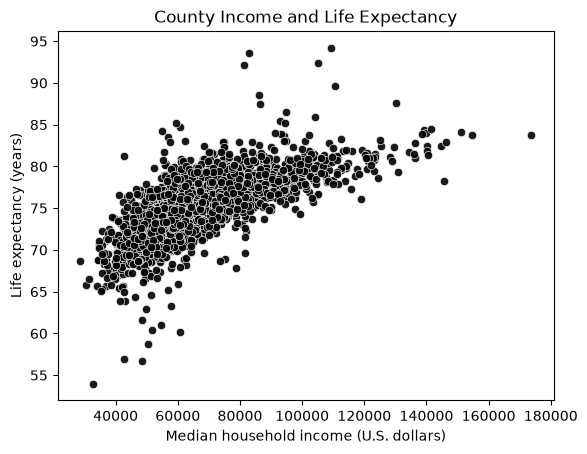

In [15]:
sns.scatterplot(
    data=analysis,
    x="median_household_income_usd",
    y="life_expectancy_years",
    alpha=0.9,
    color="black"
)
plt.title("County Income and Life Expectancy")
plt.xlabel("Median household income (U.S. dollars)")
plt.ylabel("Life expectancy (years)")
plt.show()


## Discussion: describe the scatterplot

Use four features when describing a relationship between quantitative variables:

1. **Direction:** Does `y` generally increase or decrease as `x` increases?
2. **Form:** Is the main pattern approximately linear, curved, clustered, or absent?
3. **Strength:** How tightly do points follow the main pattern?
4. **Unusual observations:** Which points fall far from the main pattern or far from most x-values?

Describe the relationship between county income and life expectancy using direction, form, strength, and unusual observations. Does the scatterplot support the prediction made earlier?


### Correlation

The **Pearson correlation**, usually written as *r*, summarizes the direction and strength of a **linear** relationship:

- it ranges from -1 through 1;
- positive values indicate a positive direction;
- negative values indicate a negative direction;
- values farther from 0 indicate a stronger linear relationship; and
- correlation has no units and does not establish causation.

Select the two quantitative features in the original relationship before calling `.corr()`.


In [16]:
correlation_matrix = analysis[['median_household_income_usd', 'life_expectancy_years']].corr()
correlation_matrix

,median_household_income_usd,life_expectancy_years
median_household_income_usd,1.000000,0.704382
life_expectancy_years,0.704382,1.000000


The correlation is approximately 0.704, indicating a moderately strong positive linear association. Correlation alone does not tell us whether a line is appropriate; we still need the scatterplot and residuals.


### Fit a line

A fitted line has the form:

$$
\hat{y} = b_0 + b_1x
$$

- `predicted y` is the predicted response;
- `b0` is the intercept; and
- `b1` is the slope.

For a simple least-squares line, the slope equals the covariance of `x` and `y` divided by the variance of `x`. The intercept positions that line through the point formed by the two feature means.


In [17]:
x = analysis["median_household_income_usd"]
y = analysis["life_expectancy_years"]

slope = x.cov(y) / x.var()
intercept = y.mean() - slope * x.mean()

print("Slope per dollar:", round(slope, 6))
print("Slope per $10,000:", round(slope * 10_000, 2))
print("Intercept:", round(intercept, 2))


Slope per dollar: 0.000151
Slope per $10,000: 1.51
Intercept: 65.22


The slope is easier to interpret per $10,000: counties that differ by $10,000 in median household income differ by about **1.51 predicted years of life expectancy**, on average, according to this line.

The intercept predicts life expectancy when income equals $0. That value is far outside the observed income range, so it positions the line mathematically but is not a meaningful county prediction. This is an example of why model coefficients must be interpreted in context.


`sns.regplot()` displays the scatterplot and a least-squares regression line. The shaded region represents uncertainty in the estimated mean line; it is not the range containing individual counties.


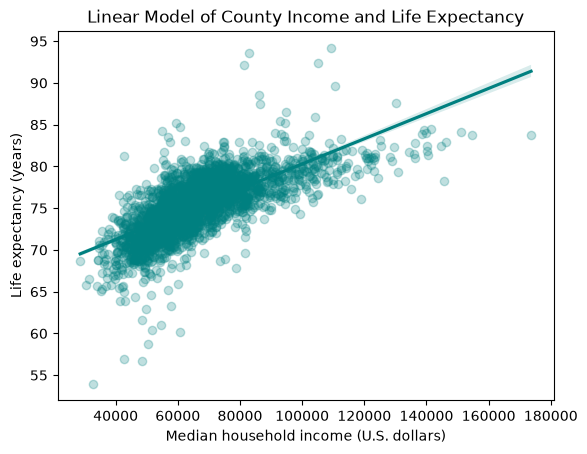

In [18]:
sns.regplot(
    data=analysis,
    x="median_household_income_usd",
    y="life_expectancy_years",
    color="teal",
    scatter_kws={"alpha": 0.25}
)
plt.title("Linear Model of County Income and Life Expectancy")
plt.xlabel("Median household income (U.S. dollars)")
plt.ylabel("Life expectancy (years)")
plt.show()


`scatter_kws` supplies options specifically to the scatterplot layer inside `regplot()`. Here it changes only the point transparency; the model and source values are unchanged.


### R-squared

**R-squared** describes the proportion of observed variation in the response that is accounted for by the fitted model. For a simple linear model with an intercept, R-squared equals the squared correlation.


In [19]:
correlation = correlation_matrix.loc['median_household_income_usd', 'life_expectancy_years']
print(correlation)
r_squared = (correlation**2)*100
r_squared

0.7043821660509006


np.float64(49.61542358505586)

The model accounts for about 49.6% of the county-level variation in life expectancy. That is substantial, but it also means that about half of the observed variation is not accounted for by this one-feature line.

R-squared is not the percentage of counties predicted correctly, and it does not measure causation.


### Predicted values and residuals

A **predicted value** is the point on the fitted line for a county's income. A **residual** is the observed response minus its predicted response:

$$
\text{residual} = y - \hat{y}
$$

- a positive residual means observed life expectancy is above the line;
- a negative residual means it is below the line; and
- a residual near zero means the line predicts that observation closely.

The calculation below creates a new feature by performing the calculation for every row and storing the resulting values in the DataFrame.


In [20]:
analysis['predicted_life_expectancy'] = (intercept+slope*analysis['median_household_income_usd'])

analysis['residual_years']=(analysis['life_expectancy_years']-analysis['predicted_life_expectancy'])
analysis.head()

,county_fips,county,state,median_household_income_usd,life_expectancy_years,age_65_plus_percent,primary_care_physicians_per_100000,predicted_life_expectancy,residual_years
1,02016,Aleutians West Census Area,AK,104159.0,85.915167,7.054264,59.30026,80.923364,4.991804
2,02020,Anchorage Borough,AK,93881.0,76.342569,13.294416,116.27059,79.373938,-3.031369
3,02050,Bethel Census Area,AK,62140.0,68.864695,8.850966,86.22083,74.588927,-5.724232
7,02068,Denali Borough,AK,86118.0,88.591762,13.446970,62.77464,78.203652,10.388110
8,02070,Dillingham Census Area,AK,62598.0,68.174982,12.524419,251.46689,74.657971,-6.482989


### Use a residual plot to check the line

A useful linear model should leave residuals scattered around zero without a strong curve or other systematic pattern. `plt.axhline(0)` draws the horizontal reference line representing a residual of zero.


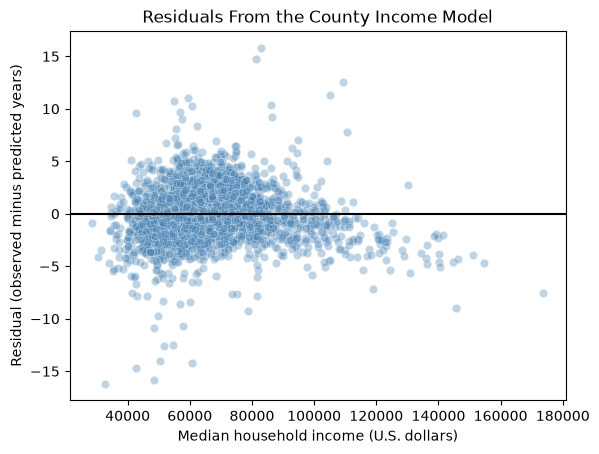

In [21]:
sns.scatterplot(
    data=analysis,
    x="median_household_income_usd",
    y="residual_years",
    alpha=0.35,
    color="steelblue"
)
plt.axhline(0, color="black")
plt.title("Residuals From the County Income Model")
plt.xlabel("Median household income (U.S. dollars)")
plt.ylabel("Residual (observed minus predicted years)")
plt.show()


The residuals remain distributed above and below zero across the income range, so the line captures the broad positive trend. There is also a mild systematic pattern: counties near the lower and upper ends tend to fall somewhat below the line, while many middle-income counties fall above it. The line is a useful first summary, not a complete model. This pattern is much less pronounced than the curve in the poor-fit example, but it is a reason to avoid claiming that the relationship is perfectly linear.


Large residuals can generate follow-up questions, but a residual does not identify a cause.


### Can another feature add useful information?

Income is not the only county characteristic that may be related to life expectancy. We will examine two possible **covariates**—additional predictor features that may help describe differences among counties with similar incomes:

- the percentage of residents age 65 or older; and
- the number of primary-care physicians per 100,000 residents.

To make the differences easy to visualize, we will convert each quantitative feature into **tertiles**, or three groups containing approximately equal numbers of counties. Quartiles are common when summarizing a distribution, but they would require four colors and four fitted lines. Tertiles are not inherently more statistically correct; they are a practical choice here because three groups keep the figures readable while still allowing us to compare lower, middle, and higher values. These are descriptive groups, not medical thresholds.

`pd.qcut()` creates groups from sample quantiles. Setting `q=3` requests three equal-frequency groups, and `labels` gives those groups readable names. Unlike `pd.cut()`, `qcut()` calculates the boundaries from the data rather than requiring us to hard-code them.


In [22]:
analysis['age_65_group'] = pd.qcut(analysis['age_65_plus_percent'], q=3, labels=['younger', 'middle', 'older'])

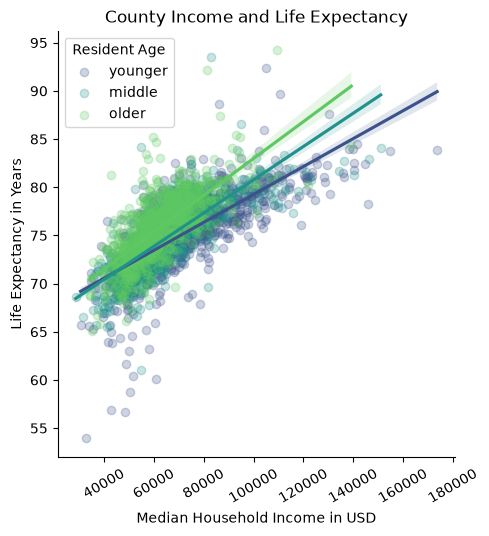

In [23]:
sns.lmplot(
    data=analysis,
    x='median_household_income_usd',
    y='life_expectancy_years',
    hue='age_65_group', 
    palette='viridis',
    scatter_kws={'alpha': 0.25},
    legend=False
)

plt.title('County Income and Life Expectancy')
plt.xlabel('Median Household Income in USD')
plt.ylabel('Life Expectancy in Years')
plt.xticks(rotation=30)
plt.legend(title='Resident Age')
plt.show()

Check the number of counties assigned to each category.


### Percentage of residents age 65 or older

`sns.lmplot()` displays a scatterplot with fitted regression lines. Setting `hue="age_65_group"` assigns a color to each age category and fits a separate line for each group. These lines help us see whether counties with similar incomes tend to have different life expectancies across age categories. They are a visual comparison, not yet the single combined model calculated below.

`legend=False` prevents `lmplot()` from drawing its automatic legend so we can add one clear legend with a human-readable title. `plt.xticks(rotation=30)` rotates the income labels so large values are easier to distinguish.


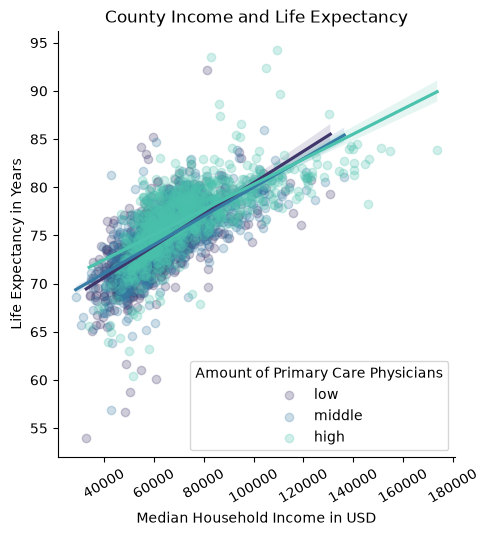

In [24]:
analysis['primary_care_group'] = pd.qcut(analysis['primary_care_physicians_per_100000'], q=3, labels=['low', 'middle', 'high'])

sns.lmplot(
    data=analysis,
    x='median_household_income_usd',
    y='life_expectancy_years',
    hue='primary_care_group', 
    palette='mako',
    scatter_kws={'alpha': 0.25},
    legend=False
)

plt.title('County Income and Life Expectancy')
plt.xlabel('Median Household Income in USD')
plt.ylabel('Life Expectancy in Years')
plt.xticks(rotation=30)
plt.legend(title='Amount of Primary Care Physicians')
plt.show()

## Discussion: does age composition add information?

At similar income levels, how do the fitted lines differ among counties with lower, middle, and higher shares of residents age 65 or older?


### Primary-care access

Repeat the same visual comparison using primary-care physicians per 100,000 residents. Because the plotting structure is identical, the amount of separation among the lines can be compared with the age example.


## Discussion: does primary-care access add information?

How does the separation among these fitted lines compare with the separation in the age-composition figure?


### Compare R-squared values

A categorical feature must be represented numerically before it can enter a linear-model calculation. `pd.get_dummies()` creates 0/1 indicator columns for the categories. `drop_first=True` keeps one category as a reference and avoids storing redundant information.

The function below performs the same least-squares calculation for several predictors and returns R-squared. The matrix calculation is a preview of multiple linear regression; the important result for this lesson is the comparison among models.


In [25]:

def calculate_r_squared(data, categorical_features):
    predictors = pd.get_dummies(
        data[
            ["median_household_income_usd", *categorical_features]
        ],
        columns=categorical_features,
        drop_first=True,
        dtype=float
    )
    predictors.insert(0, "intercept", 1.0)

    x = predictors.to_numpy()
    y = data["life_expectancy_years"].to_numpy()
    coefficients = np.linalg.lstsq(x, y, rcond=None)[0]
    predicted = x @ coefficients

    residual_sum_squares = ((y - predicted) ** 2).sum()
    total_sum_squares = ((y - y.mean()) ** 2).sum()
    return 1 - residual_sum_squares / total_sum_squares


In [26]:
model_comparison = pd.Series(
    {
        "Income only": calculate_r_squared(
            analysis, []
        ),
        "Income + age category": calculate_r_squared(
            analysis, ["age_65_group"]
        ),
        "Income + primary-care category": calculate_r_squared(
            analysis, ["primary_care_group"]
        ),
        "Income + both categories": calculate_r_squared(
            analysis,
            ["age_65_group", "primary_care_group"]
        )
    },
    name="r_squared"
)

model_comparison.round(3)


Income only                       0.496
Income + age category             0.556
Income + primary-care category    0.510
Income + both categories          0.568
Name: r_squared, dtype: float64

On the same 2,904 counties, the income-only model has an R-squared of approximately 0.496. Adding age category raises R-squared to approximately 0.556. Adding primary-care category instead raises it only to approximately 0.510. The model containing all three features—income, age category, and primary-care category—has an R-squared of approximately 0.568.

Thus, age category adds substantially more information than primary-care category, and primary-care category adds only a modest amount beyond income and age. A greater R-squared describes fit to these observed counties. Demonstrating predictive performance for new counties would require evaluating the model on data that were not used to fit it.


## Step 6 — Conclusion

Median household income and life expectancy had a moderately strong positive, approximately linear association across counties with all four required measures in the 2025 release. The correlation was about 0.704. The fitted line predicted approximately 1.51 additional years of life expectancy for a $10,000 difference in median household income and accounted for about 49.6% of the observed county-level variation.

Counties with similar incomes still differed substantially, so income alone does not determine life expectancy. Age composition added substantial information to the income-only model in this dataset. Primary-care access added much less, illustrating that a plausible covariate does not necessarily improve a model by much.


To make the age model more concrete, calculate predictions for counties representing two income levels and two age-composition groups. These are model-based examples, not forecasts for named counties.


In [27]:
age_predictors = pd.get_dummies(
    analysis[
        ["median_household_income_usd", "age_65_group"]
    ],
    columns=["age_65_group"],
    drop_first=True,
    dtype=float
)
age_predictors.insert(0, "intercept", 1.0)

age_coefficients = np.linalg.lstsq(
    age_predictors.to_numpy(),
    analysis["life_expectancy_years"].to_numpy(),
    rcond=None
)[0]

prediction_examples = pd.DataFrame(
    {
        "median_household_income_usd": [
            50_000, 50_000, 80_000, 80_000
        ],
        "age_65_group": [
            "Lower share", "Higher share",
            "Lower share", "Higher share"
        ]
    }
)

prediction_examples["age_65_group"] = pd.Categorical(
    prediction_examples["age_65_group"],
    categories=analysis["age_65_group"].cat.categories,
    ordered=True
)

example_predictors = pd.get_dummies(
    prediction_examples,
    columns=["age_65_group"],
    drop_first=True,
    dtype=float
)
example_predictors.insert(0, "intercept", 1.0)
example_predictors = example_predictors.reindex(
    columns=age_predictors.columns,
    fill_value=0
)

prediction_examples["predicted_life_expectancy"] = (
    example_predictors.to_numpy() @ age_coefficients
)

prediction_examples.round(1)


C:\Users\mvege\AppData\Local\Temp\ipykernel_13152\2665687425.py:29: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  prediction_examples["age_65_group"] = pd.Categorical(


,median_household_income_usd,age_65_group,predicted_life_expectancy
0,50000,NaN,71.7
1,50000,NaN,71.7
2,80000,NaN,76.5
3,80000,NaN,76.5


## Discussion: interpret the county model

1. What does the slope say, and what causal claim does it not support?

2. Why is a residual of +3 years not a “score” proving that a county performed well?

3. What evidence from the county analysis supports using the fitted line as a useful first summary rather than a complete model?

4. What does the comparison of the two covariates demonstrate about selecting features for a model?

5. At an income of $50,000, how do the predictions differ between the lower-share and higher-share age groups?

6. Within the same age-composition group, how does changing income from $50,000 to $80,000 change predicted life expectancy?


## Step 7 — Limitation

- This is an observational county-level association, not a controlled experiment.
- The model does not show that changing household income alone would cause life expectancy to change by the fitted amount.
- County averages do not describe every person within a county; drawing an individual-level conclusion from a group-level relationship is an **ecological fallacy**.
- Income may stand in for many related community conditions and historical processes.
- Different measures in the annual release use different source periods.
- Counties missing one or more of the four required measures are excluded from the analysis.
- Predictions outside the observed income range would be extrapolations and should not be trusted automatically.


# When is a linear model not a good fit?

Software can fit a line to almost any pair of quantitative features. The existence of a line—or even a large correlation—does not show that the line is a useful summary.

Warning signs include:

1. a curved pattern;
2. distinct groups with different relationships;
3. an influential outlier that pulls the line;
4. a high-leverage point far from the other x-values;
5. residuals whose spread changes substantially; or
6. no meaningful relationship.


## A strong relationship that is not linear

EPA fuel-economy data provide a useful contrast. The following file contains non-hybrid gasoline vehicle configurations from model year 2024.


In [28]:
vehicles = pd.read_csv(
    "data/epa_gasoline_vehicle_configurations_2024.csv"
)

vehicles[["combined_mpg", "co2_grams_per_mile"]].describe().round(1)


,combined_mpg,co2_grams_per_mile
count,839.0,839.0
mean,21.9,323.3
std,5.2,81.8
min,9.0,159.0
25%,18.0,261.5
50%,21.0,320.0
75%,25.0,376.0
max,39.0,786.0


Combined MPG and carbon dioxide emitted per mile are strongly related, but the raw-scale pattern is curved: each additional MPG has a larger effect at the low-MPG end than at the high-MPG end.


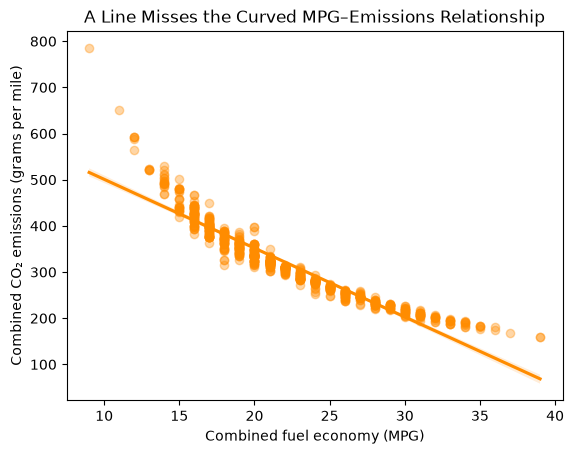

In [29]:
sns.regplot(
    data=vehicles,
    x="combined_mpg",
    y="co2_grams_per_mile",
    color="darkorange",
    scatter_kws={"alpha": 0.35}
)
plt.title("A Line Misses the Curved MPG–Emissions Relationship")
plt.xlabel("Combined fuel economy (MPG)")
plt.ylabel("Combined CO₂ emissions (grams per mile)")
plt.show()


In [30]:
vehicle_correlation = vehicles[
    ["combined_mpg", "co2_grams_per_mile"]
].corr().loc["combined_mpg", "co2_grams_per_mile"]

round(vehicle_correlation, 3)


np.float64(-0.947)

The correlation is approximately -0.95—stronger in absolute value than the county correlation. Nevertheless, the scatterplot shows that one straight line systematically misses the relationship.


Fit the line only so we can inspect what it leaves behind.


In [31]:
vehicle_x = vehicles["combined_mpg"]
vehicle_y = vehicles["co2_grams_per_mile"]

vehicle_slope = vehicle_x.cov(vehicle_y) / vehicle_x.var()
vehicle_intercept = (
    vehicle_y.mean()
    - vehicle_slope * vehicle_x.mean()
)

vehicles = vehicles.assign(
    predicted_co2=(
        vehicle_intercept
        + vehicle_slope * vehicles["combined_mpg"]
    )
)

vehicles = vehicles.assign(
    residual_co2=(
        vehicles["co2_grams_per_mile"]
        - vehicles["predicted_co2"]
    )
)


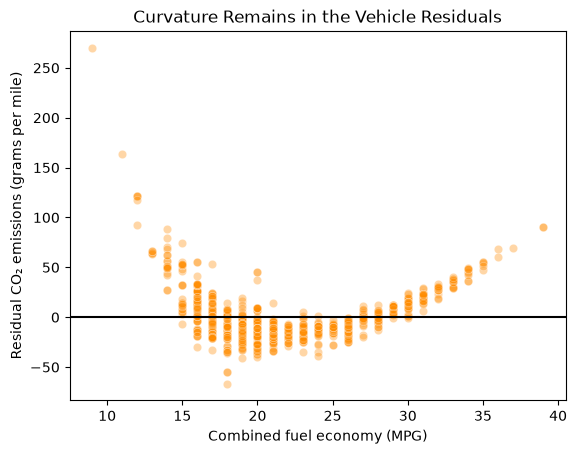

In [32]:
sns.scatterplot(
    data=vehicles,
    x="combined_mpg",
    y="residual_co2",
    alpha=0.35,
    color="darkorange"
)
plt.axhline(0, color="black")
plt.title("Curvature Remains in the Vehicle Residuals")
plt.xlabel("Combined fuel economy (MPG)")
plt.ylabel("Residual CO₂ emissions (grams per mile)")
plt.show()


The residuals form a systematic curve rather than patternless variation around zero. That is direct evidence that the line misses an important part of the relationship. A later modeling course can consider transformations or nonlinear models; the decision needed here is simply **not to use this straight line as the final summary**.


## Discussion: strong correlation, poor linear fit

How can the vehicle correlation be very strong while its linear model is inappropriate?


## Anscombe's warning: calculate, but always visualize

Statistician Francis Anscombe constructed four small datasets with nearly identical means, standard deviations, correlations, and fitted lines but very different scatterplots. We use three of them to isolate different model-fit problems.


In [33]:
anscombe = pd.read_csv("data/anscombe_selected.csv")
anscombe.groupby("dataset")[["x", "y"]].agg(
    ["mean", "std"]
).round(2)


x          y      
        mean   std mean   std
dataset                      
II       9.0  3.32  7.5  2.03
III      9.0  3.32  7.5  2.03
IV       9.0  3.32  7.5  2.03

### Dataset II: curvature


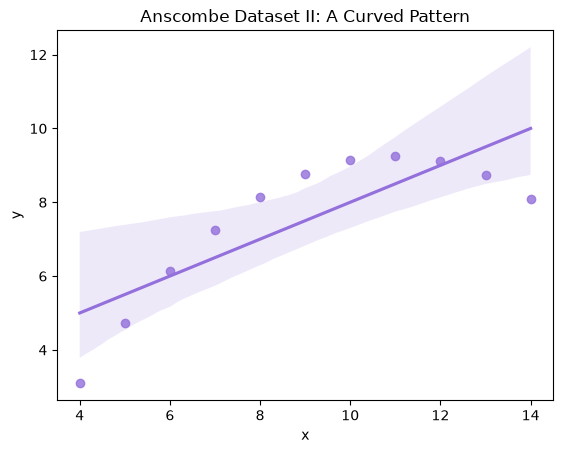

In [34]:
sns.regplot(
    data=anscombe.loc[anscombe["dataset"] == "II"],
    x="x",
    y="y",
    color="mediumpurple"
)
plt.title("Anscombe Dataset II: A Curved Pattern")
plt.show()


The curve is visible even though a line can be calculated. A residual plot would retain the same systematic bend.


### Dataset III: an influential outlier


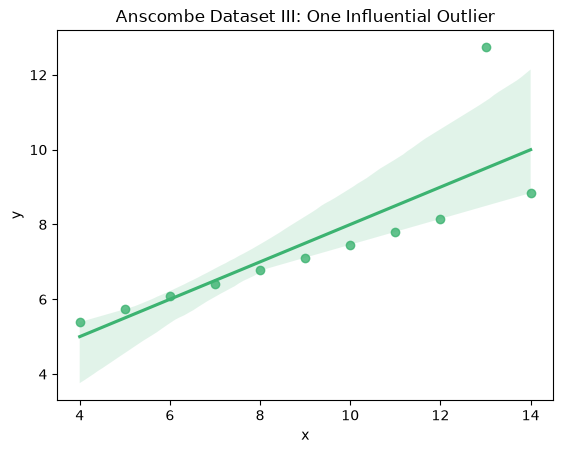

In [35]:
sns.regplot(
    data=anscombe.loc[anscombe["dataset"] == "III"],
    x="x",
    y="y",
    color="mediumseagreen"
)
plt.title("Anscombe Dataset III: One Influential Outlier")
plt.show()


Most points follow a tight line, but one vertical outlier changes the fitted result. Investigate such a point rather than automatically deleting it: it may be an error, a valid rare case, or evidence of a missing feature.


### Dataset IV: a high-leverage point


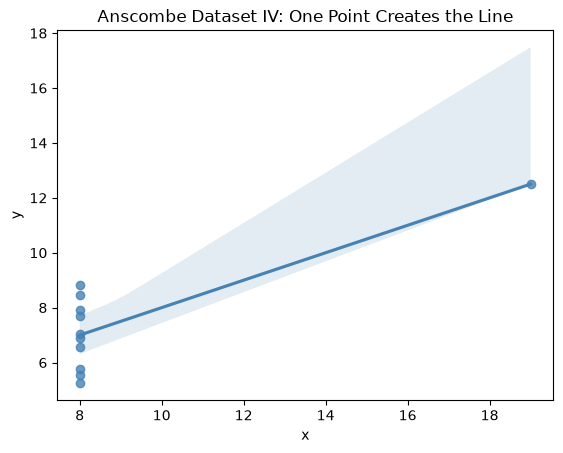

In [36]:
sns.regplot(
    data=anscombe.loc[anscombe["dataset"] == "IV"],
    x="x",
    y="y",
    color="steelblue"
)
plt.title("Anscombe Dataset IV: One Point Creates the Line")
plt.show()


Ten observations share the same x-value. The single distant x-value creates the apparent linear relationship. A correlation or fitted line reported without the scatterplot would be deeply misleading.


## Discussion: Anscombe's warnings

1. What different warnings do Anscombe datasets II, III, and IV provide?

2. What evidence should you examine before deciding that a fitted line is useful?


## Key takeaways

- A scatterplot should come before a correlation or fitted line.
- Describe direction, form, strength, and unusual observations.
- A fitted value lies on the model line; a residual is observed minus predicted.
- Slope and R-squared require contextual interpretations.
- A strong association is not necessarily linear, and a linear association is not necessarily causal.
- Patterned residuals show that a line has missed structure.
- Outliers and high-leverage points should be investigated, not removed automatically.
- Models are simplified summaries. Their usefulness depends on the question, data, fit, and limitations.
